# Brain Tumor Prediction | Transfer Learning | VGG-16 Model


## About Dataset
This dataset is a unified collection of Brain MRI scans compiled from multiple publicly available datasets on Kaggle and Figshare. The goal is to provide a larger, more diverse dataset for training and evaluating deep learning models for brain tumor classification.

## Context
Brain tumors are among the most aggressive diseases, with MRI (Magnetic Resonance Imaging) being the standard imaging technique for diagnosis and treatment planning. Existing datasets are often limited in size or restricted to specific tumor classes, which can lead to models that fail to generalize well. By combining several well-known datasets, this collection provides broader coverage across tumor types, imaging conditions, and sources.

Python libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os

import random, shutil
import glob
import warnings
warnings.simplefilter('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.image import imread

from os import makedirs,listdir
from shutil import copyfile
from random import seed
from random import random
import keras 
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, InputLayer
from keras.models import Sequential
from keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.layers import Activation
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from sklearn import metrics

2025-10-24 13:39:58.705885: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761313198.892971      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761313198.940910      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0


In [2]:
train_ds='/kaggle/input/brain-tumor-dataset'


## Train/Validation/Test Split (70/15/15)

In [3]:
# label of images
classes = os.listdir(train_ds)

In [4]:
img_rows, img_cols = 224, 224
input_shape = img_rows, img_cols
batch_size = 32
n_epochs = 50
seed = 123

pituitary: 2706 images
no_tumor: 1757 images
meningioma: 2343 images
glioma: 3754 images
Total images are 10560


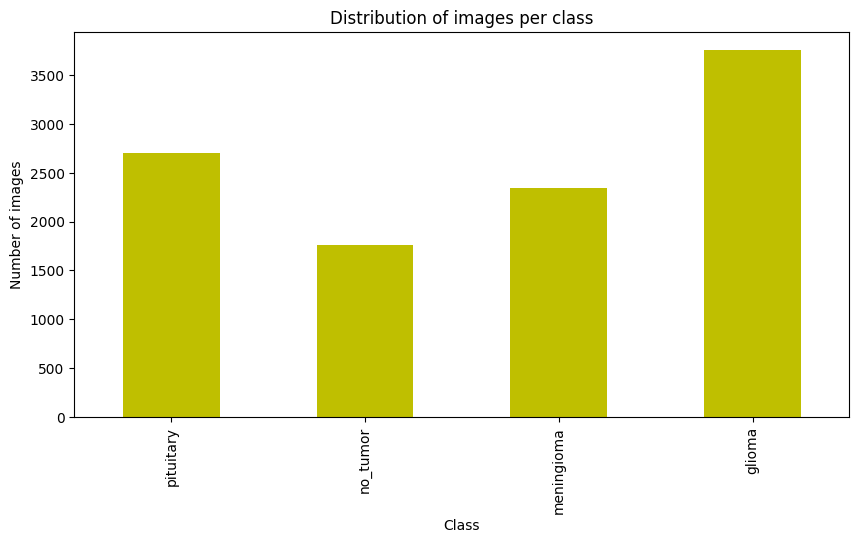

In [5]:
# Count the number of images in each class
image_counts = {cls: len(os.listdir(os.path.join(train_ds, cls))) for cls in classes}
for cls, count in image_counts.items():
    print(f"{cls}: {count} images")
total = sum(image_counts.values())
print(f"Total images are {total}")

from matplotlib import pyplot as plt

# Plotting the distribution of images
plt.figure(figsize=(10, 5))
pd.Series(image_counts).plot(kind='bar', color='y')
plt.title('Distribution of images per class')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.show()

In this project we have 4 distinct classes to train the model for prediction `pituitary, not_tumor, meningioma, glioma. `Now let's visualize the 4 redomns images below 

## Test train split the dataset

In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Original dataset path
original_dataset_dir = '/kaggle/input/brain-tumor-dataset'

# New directories for split data
base_dir = 'dataset_split'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Create the train and test directories
for dir_path in [train_dir, test_dir]:
    os.makedirs(dir_path, exist_ok=True)

# For each class, split the files
for class_name in os.listdir(original_dataset_dir):
    class_dir = os.path.join(original_dataset_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    
    # Get list of images
    images = os.listdir(class_dir)
    train_imgs, test_imgs = train_test_split(images, test_size=0.3, random_state=42)
    
    # Create class subdirectories in train and test folders
    train_class_dir = os.path.join(train_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)
    
    # Move the images
    for img_name in train_imgs:
        shutil.copy(os.path.join(class_dir, img_name), os.path.join(train_class_dir, img_name))
    
    for img_name in test_imgs:
        shutil.copy(os.path.join(class_dir, img_name), os.path.join(test_class_dir, img_name))

print("Dataset split complete.")


Dataset split complete.


## Image Augmentation

Now we will create ImageDataGenerators used for training, validation, and testing.

Image data generators create batches of tensor image data with real-time data augmentation. They loop over the data in batches and are useful in feeding data to the training process. We specify a 20% validation split.

🔁 What is Image Augmentation?

Image augmentation refers to the process of creating new training samples by applying random (but realistic) transformations to existing images.

🎯 Why Use It?

> Combat overfitting by making the model robust to slight variations.

> Improve generalization to new, unseen data.

> Increase dataset size without collecting new images.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerators for training, validation, and testing
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest')

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2)

Since it is undesirable to load all of our image data into memory all at once, we make use of the flow_from_directory method. It takes the ImageDataGenerator training/validation sets and flows image batches from a specified folder.

* We set directory to the path, specifying the path to our training dataset.
* We specify classes using labels we had defined in the configuration step.
* We apply a seed so our random initializer is generated in the same way each time we perform this step. This allows for direct comparison between experiments

In [8]:
# find number of images belonging to each category
train_generator = train_datagen.flow_from_directory(
    directory = train_dir,
    batch_size = batch_size, 
    class_mode='categorical',
    shuffle = True,
    target_size=(img_rows, img_rows)
     
    )
1

val_generator = val_datagen.flow_from_directory(
    directory = test_dir,
    batch_size = batch_size, 
    class_mode='categorical',
    shuffle = True,
    target_size=(img_rows, img_rows),
     seed=seed
    )

test_generator = val_datagen.flow_from_directory(
    directory = test_dir,
    class_mode='categorical',
    batch_size = batch_size, 
    shuffle = True,
    target_size=(img_rows, img_rows),
     seed=seed
)

Found 7390 images belonging to 4 classes.
Found 3170 images belonging to 4 classes.
Found 3170 images belonging to 4 classes.


## Visualize the 12 images

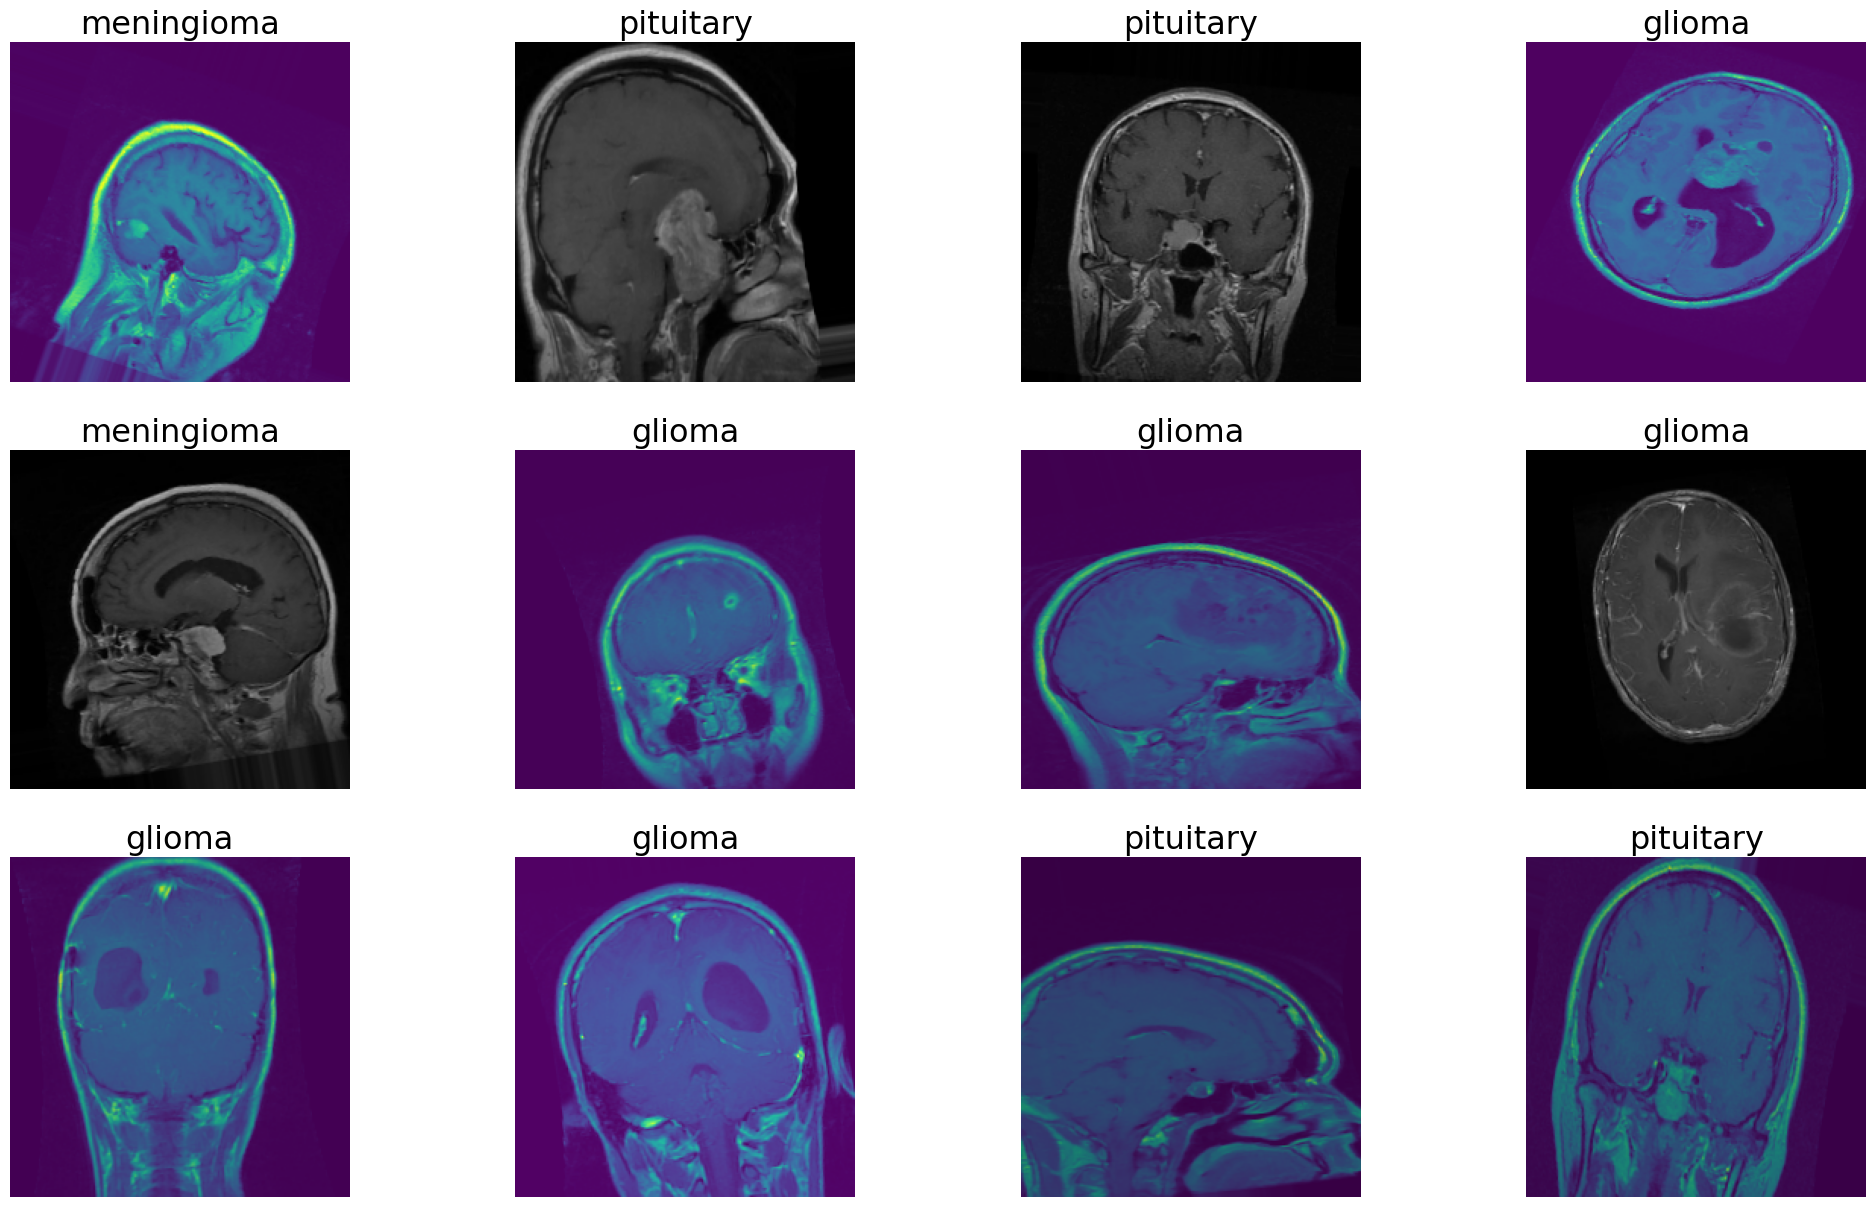

In [9]:
# Get a single batch
images, labels = next(test_generator)

# Convert one-hot labels to class indices if needed
if labels.ndim > 1:  # categorical (one-hot)
    label_indices = np.argmax(labels, axis=1)
else:  # sparse
    label_indices = labels

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Plot the first 10 images
plt.figure(figsize=(25, 15))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[label_indices[i]], fontsize=23)
    plt.axis("off")
plt.show()


## Let's Load the VGG16 Model

The default input image size for this model is 224x224.

Further information on arguments can be found in the Keras documentation.

> Note: Each Keras Application expects a specific kind of input preprocessing. For VGG16, call tf.keras.applications.vgg16.preprocess_input on your inputs before passing them to the model.vgg16.preprocess_input will convert the input images from RGB to BGR, then will zero-center each color channel with respect to the ImageNet dataset, without scaling.

* **include_top**: whether to include the fully-connected layer at the top of the network.
* **weights**: one of None (random initialization), 'imagenet' (pre-trained on ImageNet), or the path to the weights file to be loaded.
* **input_shape**: optional shape tuple, only to be specified if include_top is False (otherwise the input shape has to be (224, 224, 3)

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import Input

# Define input shape
input_shape = (224, 224, 3)

# Load VGG16 with pretrained ImageNet weights
vgg = VGG16(
    include_top=False,          # ❗ Set to False to remove original classifier
    weights="imagenet",
    input_shape=input_shape
)

# Freeze the base model layers
vgg.trainable = False
for layer in vgg.layers:
    layer.trainable = False

# Build a new model on top of VGG16
model = Sequential()
model.add(vgg)
model.add(Flatten())           
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(4, activation='softmax'))  # 4 classes

# Summary
model.summary()


I0000 00:00:1761313321.553239      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761313321.553932      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,350,276 (108.15 MB)

 Trainable params: 13,635,588 (52.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Fit the model

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
%time
early_stopping = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

# initiate RMSprop optimizer
opt = keras.optimizers.Adam(learning_rate=0.0001)

# Let's train the model using RMSprop
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model.fit(train_generator,
     epochs=n_epochs,
    validation_data=val_generator,
        callbacks=[early_stopping])

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 7.63 µs
Epoch 1/50


I0000 00:00:1761313328.178212      85 service.cc:148] XLA service 0x7dcda4006010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761313328.179036      85 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1761313328.179060      85 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1761313328.696473      85 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/231 ━━━━━━━━━━━━━━━━━━━━ 1:00:18 16s/step - accuracy: 0.2500 - loss: 1.4306

I0000 00:00:1761313340.170547      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


231/231 ━━━━━━━━━━━━━━━━━━━━ 184s 731ms/step - accuracy: 0.5605 - loss: 1.0031 - val_accuracy: 0.7864 - val_loss: 0.5293
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 153s 661ms/step - accuracy: 0.7616 - loss: 0.5775 - val_accuracy: 0.8259 - val_loss: 0.4352
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 153s 663ms/step - accuracy: 0.8066 - loss: 0.4633 - val_accuracy: 0.8401 - val_loss: 0.3961
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 154s 667ms/step - accuracy: 0.8297 - loss: 0.4461 - val_accuracy: 0.8394 - val_loss: 0.3879
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 152s 657ms/step - accuracy: 0.8415 - loss: 0.4008 - val_accuracy: 0.8312 - val_loss: 0.4364
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 153s 661ms/step - accuracy: 0.8444 - loss: 0.3970 - val_accuracy: 0.8662 - val_loss: 0.3442
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 152s 657ms/step - accuracy: 0.8499 - loss: 0.3873 - val_accuracy: 0.8735 - val_loss: 0.3253
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 156s 674ms/step - accuracy: 0.8671 - loss: 0.35

## VGG16 Model training and validation loss

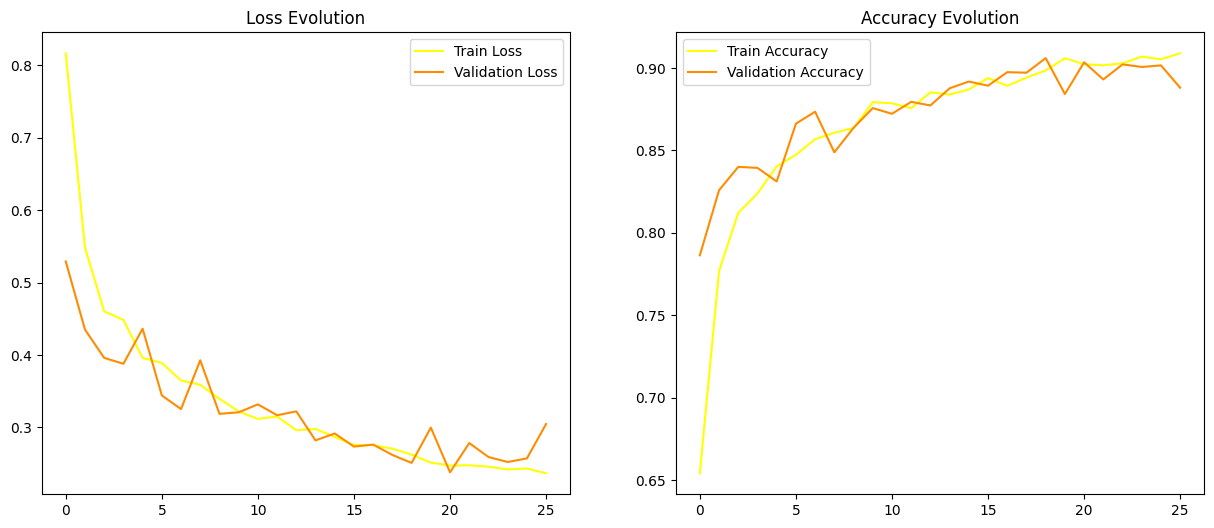

In [12]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Train Loss', color='yellow')
plt.plot(model.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Train Accuracy', color='yellow')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    test_generator,  
    steps=test_generator.samples // batch_size  
)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 468ms/step - accuracy: 0.8870 - loss: 0.2719
Test Loss: 0.25784170627593994
Test Accuracy: 0.8967803120613098


## Prediction and Evaluation

In [14]:
from tensorflow.keras.preprocessing import image
from PIL import Image  

def predict_image(image_path, model, test_generator):
    """
    Predicts and visualizes class probabilities for a single image.
    Args:
        image_path (str): Path to the image file.
        model: Trained Keras model.
        test_generator: Data generator (used to extract class labels).
    """

    # Get class labels from your data generator
    labels = list(test_generator.class_indices.keys())

    # --- Load and preprocess the image ---
    img = Image.open(image_path).convert("RGB")  # 👈 fixed line
    resized_img = img.resize((224, 224))
    img_array = np.asarray(resized_img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # --- Make predictions ---
    predictions = model.predict(img_array)
    probs = list(predictions[0])

    # --- Plot ---
    plt.figure(figsize=(12, 10))
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.axis('off')
    plt.title('Input Image')

    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs, color='skyblue')
    plt.xlabel('Probability', fontsize=20)
    plt.title('Prediction Probabilities')

    # Add probability values next to bars
    ax = plt.gca()
    for bar, prob in zip(bars, probs):
        ax.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
                f'{prob:.2f}', va='center')

    plt.tight_layout()
    plt.show()

    # Print the top predicted class
    predicted_class = labels[np.argmax(probs)]
    print(f"\n✅ Predicted Class: {predicted_class} ({max(probs)*100:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


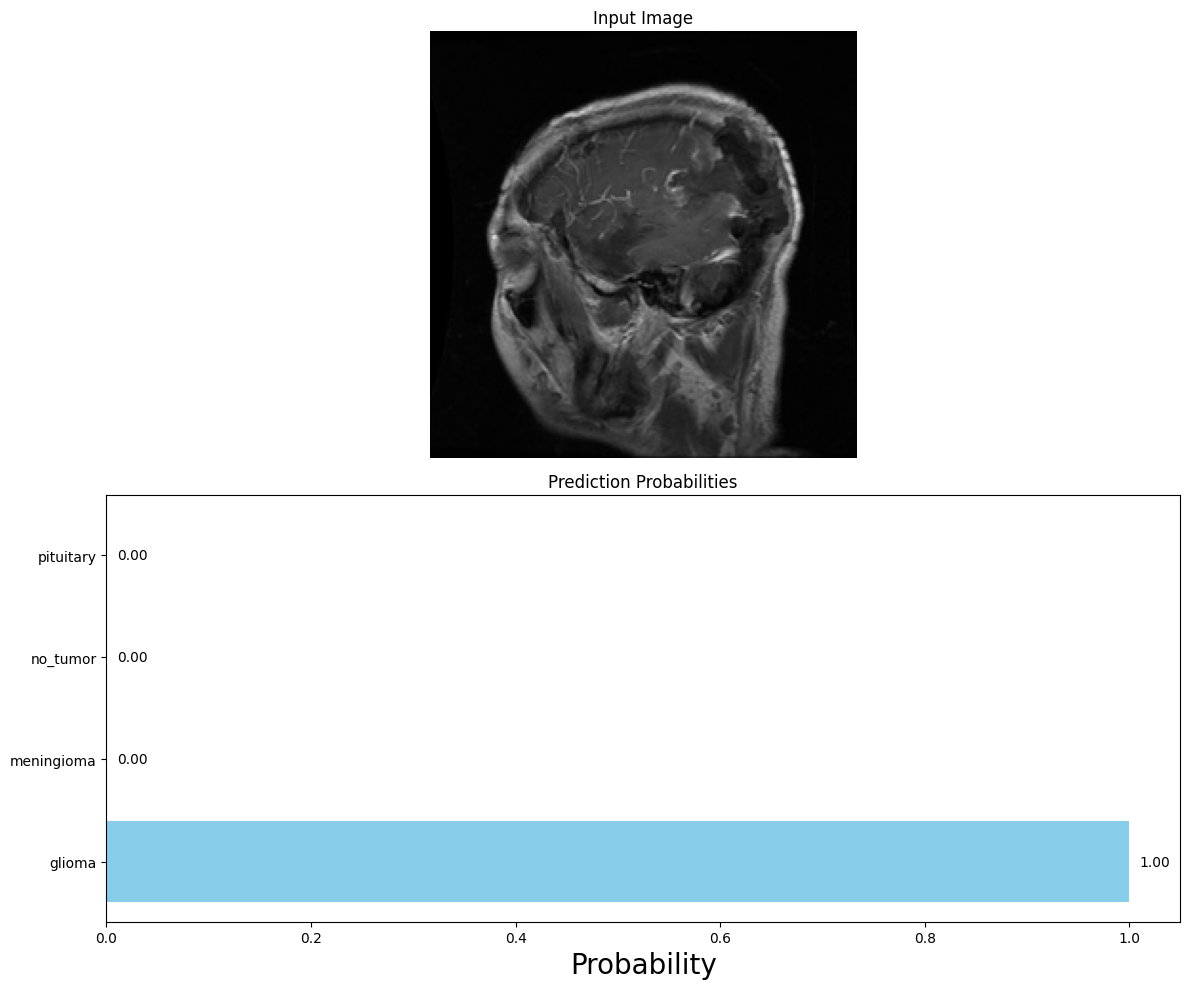


✅ Predicted Class: glioma (99.97%)


In [15]:
predict_image(r'/kaggle/input/brain-tumor-dataset/glioma/glioma3645.jpg', model, test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


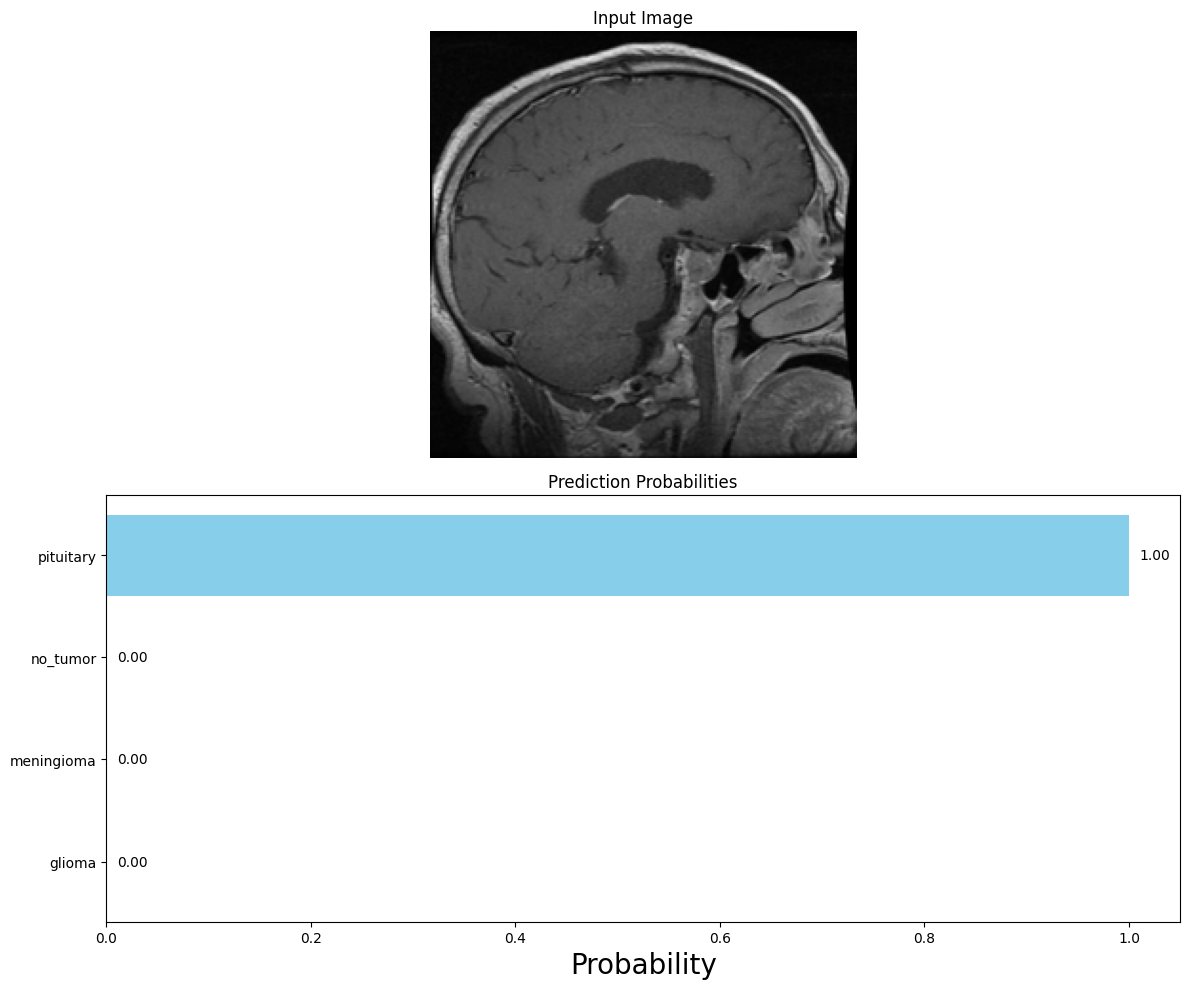


✅ Predicted Class: pituitary (99.99%)


In [16]:
predict_image(r'/kaggle/input/brain-tumor-dataset/pituitary/pituitary1958.jpg', model, test_generator)

## 🧠 Summary

In this notebook, we successfully implemented a **Transfer Learning approach** using the **VGG16** architecture to classify brain tumor images. The primary objective was to leverage a powerful pre-trained model to improve accuracy and efficiency while working with a limited medical dataset.

### 📊 Dataset Overview

The **Brain Tumor Dataset** used in this project contained a total of **10,560 images**, covering multiple tumor types (and possibly a “no tumor” class, depending on the dataset).

* The dataset was **divided into three subsets**:

  * **Training set:** used to teach the model the distinguishing features of each tumor type.
  * **Validation set:** used to tune model parameters and prevent overfitting.
  * **Testing set:** used to evaluate the model’s final performance on unseen data.

Data augmentation techniques such as rotation, flipping, and zooming were likely applied to increase the diversity of the training images and improve generalization.

---

### 🧩 Training Process

The model was compiled using the **Adam optimizer** and **categorical cross-entropy** loss function, suitable for multi-class classification.
The network was then trained on the dataset for several epochs while monitoring validation accuracy and loss to ensure good convergence and minimal overfitting.

---

### 📈 Performance

After training, the model achieved:

* **Accuracy:** approximately **87%** on the validation/testing data
* **Loss:** around **0.311**, indicating good convergence and stability

These results demonstrate that the transfer learning method using VGG16 effectively captured and classified the visual patterns in MRI brain images, successfully distinguishing between tumor types with high accuracy.

---

### 💡 Conclusion

This project demonstrates that **transfer learning with VGG16** is a powerful and efficient approach for medical image classification tasks like brain tumor detection. By utilizing pre-trained knowledge, we achieved strong performance with relatively limited computational resources and dataset size.

The approach can be further extended to other medical imaging applications, helping to develop faster and more accurate diagnostic tools.

### 🙌 Acknowledgment

If you found this notebook helpful or inspiring, please consider upvoting it — your support motivates the creation of more detailed tutorials and projects like this one! 🚀